# ☕ Coffee Analytics — End-to-End Analysis Notebook

## 🎯 Project Goal
Build a complete, production-style analytics workflow for coffee retail transactions, covering:
- Data loading (local + Kaggle-friendly)
- Data quality checks and cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Business insights and actionable recommendations

## 🔗 Data Source
- Kaggle: [Coffee Analysis Project Data](https://www.kaggle.com/datasets/ahmedmohamedibrahim1/coffee-analisys-project/data)
- Local file used in this notebook: `Coffee analysis/Dataset/COFFEE_ANALISYS_PROJECT.xlsx`

## 🧭 Analysis Questions
1. What are the most popular coffee products?
2. Which days/times generate the highest sales?
3. What is the average order value?
4. How do product categories contribute to total revenue?

---

> This notebook is designed to run both locally and in Kaggle with minimal path changes.

## ⚙️ Environment Setup
The next cells import libraries, find the dataset automatically, and inspect workbook sheets.

In [3]:
# ==========================================
# 1) Imports + Data Path
# ==========================================
import warnings
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Ensure Excel engine dependency exists
try:
    import openpyxl  # noqa: F401
except ImportError:
    print("Installing missing dependency: openpyxl ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])
    import openpyxl  # noqa: F401

# Exact local path provided by you
local_file_path = Path(r"D:/Projects--Kaggle-/Coffee analysis/Dataset/COFFEE_ANALISYS_PROJECT.xlsx")

# Kaggle fallback paths
kaggle_candidates = [
    Path("/kaggle/input/datasets/ahmedmohamedibrahim1/coffee-analisys-project/COFFEE_ANALISYS_PROJECT.xlsx"),
    Path("/kaggle/input/coffee-analisys-project/COFFEE_ANALISYS_PROJECT.xlsx"),
]

if local_file_path.exists():
    file_path = local_file_path
else:
    file_path = next((p for p in kaggle_candidates if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Dataset file not found. Checked local and Kaggle paths."
    )

print(f"✅ Data file found: {file_path}")
xls = pd.ExcelFile(file_path, engine="openpyxl")
print("Available sheets:", xls.sheet_names)

✅ Data file found: D:\Projects--Kaggle-\Coffee analysis\Dataset\COFFEE_ANALISYS_PROJECT.xlsx
Available sheets: ['Top 5 Customer', 'Dashboard', 'Country Barchart', 'Total Sales', 'orders', 'customers', 'products']


In [4]:
# ==========================================
# 3) Flexible Sheet Loader
# ==========================================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

sheet_lookup = {s.lower(): s for s in xls.sheet_names}

if {"orders", "customers", "products"}.issubset(sheet_lookup):
    mode = "multi_sheet"
    orders_df = normalize_columns(pd.read_excel(file_path, sheet_name=sheet_lookup["orders"], engine="openpyxl"))
    customers_df = normalize_columns(pd.read_excel(file_path, sheet_name=sheet_lookup["customers"], engine="openpyxl"))
    products_df = normalize_columns(pd.read_excel(file_path, sheet_name=sheet_lookup["products"], engine="openpyxl"))

    print("✅ Mode:", mode)
    print("orders:", orders_df.shape, "customers:", customers_df.shape, "products:", products_df.shape)
else:
    mode = "single_sheet"
    raw_df = normalize_columns(pd.read_excel(file_path, sheet_name=xls.sheet_names[0], engine="openpyxl"))

    print("✅ Mode:", mode)
    print("raw sheet:", raw_df.shape)

mode

✅ Mode: multi_sheet
orders: (794, 14) customers: (1000, 9) products: (48, 7)


'multi_sheet'

In [5]:
# ==========================================
# 4) Data Cleaning + Feature Engineering
# ==========================================
if mode == "multi_sheet":
    df = orders_df.copy()

    if "Customer ID" in df.columns and "Customer ID" in customers_df.columns:
        customer_cols = [c for c in ["Customer ID", "City", "Postcode", "Country"] if c in customers_df.columns]
        df = df.merge(customers_df[customer_cols], on="Customer ID", how="left")

    if "Product ID" in df.columns and "Product ID" in products_df.columns:
        product_cols = [c for c in ["Product ID", "Profit", "Coffee Type", "Coffee Type Name", "Roast Type Name"] if c in products_df.columns]
        df = df.merge(products_df[product_cols], on="Product ID", how="left", suffixes=("", "_prod"))

    if "Order Date" in df.columns:
        df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
        df["Year"] = df["Order Date"].dt.year
        df["Month"] = df["Order Date"].dt.month_name()
        df["Month_Num"] = df["Order Date"].dt.month
        df["Day_Name"] = df["Order Date"].dt.day_name()
        df["Week"] = df["Order Date"].dt.isocalendar().week.astype("Int64")

    if "Sales" not in df.columns and {"Quantity", "Unit Price"}.issubset(df.columns):
        df["Sales"] = df["Quantity"] * df["Unit Price"]

    if {"Profit", "Quantity"}.issubset(df.columns):
        df["Total_Profit"] = df["Profit"] * df["Quantity"]
    elif "Profit" in df.columns:
        df["Total_Profit"] = df["Profit"]

else:
    # Fallback for simple 2-column style sheet
    temp = raw_df.copy()
    temp = temp.dropna(how="all")

    # If first valid row looks like a header, promote it
    if len(temp) > 1:
        first_row = temp.iloc[0].astype(str).str.lower().tolist()
        if any("customer" in v for v in first_row) and any("sale" in v for v in first_row):
            temp.columns = temp.iloc[0]
            temp = temp.iloc[1:]

    temp.columns = ["Customer_Name", "Sales"] if temp.shape[1] >= 2 else ["Category"]
    if "Sales" in temp.columns:
        temp["Sales"] = pd.to_numeric(temp["Sales"], errors="coerce")

    df = temp.copy()

# General clean-up
if "Sales" in df.columns:
    df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

initial_shape = df.shape
df = df.dropna(how="all")

print("Initial shape:", initial_shape)
print("Final shape after cleanup:", df.shape)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

display(df.head())

Initial shape: (794, 25)
Final shape after cleanup: (794, 25)

Missing values:


Order ID        0
Loyalty Card    0
Week            0
Day_Name        0
Month_Num       0
Month           0
Year            0
Coffee Type     0
Profit          0
Country_y       0
dtype: int64

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country_x,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Country_y,Profit,Coffee Type,Year,Month,Month_Num,Day_Name,Week,Total_Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.00,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,United States,0.60,Rob,2019,September,9,Thursday,36,1.19
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.50,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,United States,0.91,Exc,2019,September,9,Thursday,36,4.54
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.00,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,United States,1.17,Ara,2021,June,6,Thursday,24,1.17
3,IPP-31994-879,2022-01-21,65223-29612-CB,E-D-0.5,3,Shaylynn Lobe,slobe6@nifty.com,United States,0.50,7.29,21.87,Excelsa,Dark,Yes,Dayton,45440,United States,0.80,Exc,2022,January,1,Friday,3,2.41
4,EZT-46571-659,2019-01-02,03396-68805-ZC,R-M-0.5,3,Guthrey Petracci,gpetracci8@livejournal.com,United States,0.50,5.97,17.91,Robusta,Medium,No,Los Angeles,90045,United States,0.36,Rob,2019,January,1,Wednesday,1,1.07


## 📊 EDA — Quick Profile
We start with core KPIs and distribution checks before deeper segmentation.

In [6]:
# ==========================================
# 5) Core KPIs
# ==========================================
if "Sales" in df.columns:
    total_sales = df["Sales"].sum(skipna=True)
    avg_order_value = df["Sales"].mean(skipna=True)
    median_order_value = df["Sales"].median(skipna=True)
    max_order_value = df["Sales"].max(skipna=True)

    kpi = pd.DataFrame({
        "Metric": ["Total Sales", "Average Order Value", "Median Order Value", "Max Order Value", "Number of Records"],
        "Value": [total_sales, avg_order_value, median_order_value, max_order_value, len(df)]
    })
    display(kpi)
else:
    print("Sales column not available. Please check source structure.")

,Metric,Value
0,Total Sales,"34,788.15"
1,Average Order Value,43.81
2,Median Order Value,29.16
3,Max Order Value,204.93
4,Number of Records,794.00


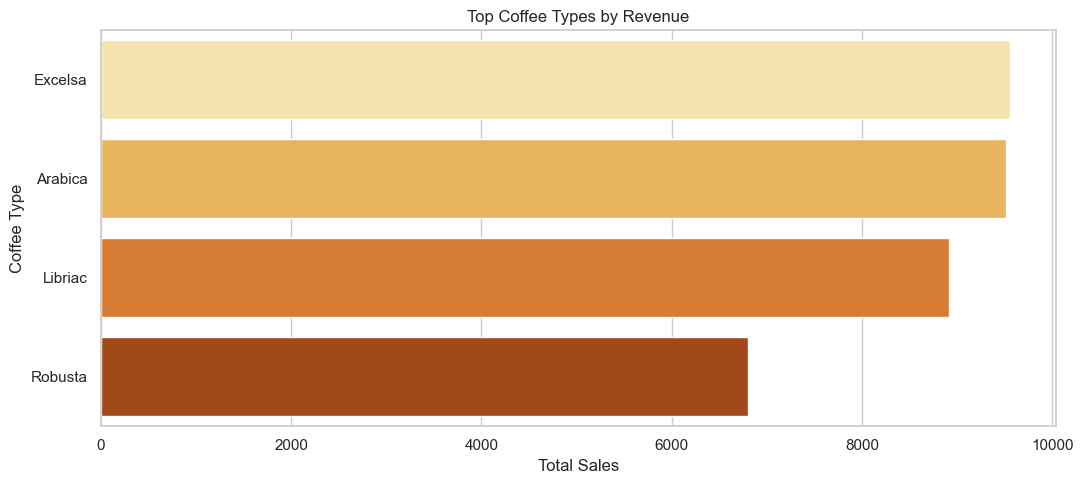

In [7]:
# ==========================================
# 6) Popular Products / Customers
# ==========================================
plt.figure(figsize=(11, 5))

if "Coffee Type Name" in df.columns and "Sales" in df.columns:
    top = df.groupby("Coffee Type Name", dropna=False)["Sales"].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top.values, y=top.index, palette="YlOrBr")
    plt.title("Top Coffee Types by Revenue")
    plt.xlabel("Total Sales")
    plt.ylabel("Coffee Type")

elif "Customer_Name" in df.columns and "Sales" in df.columns:
    top = df.groupby("Customer_Name", dropna=False)["Sales"].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top.values, y=top.index, palette="YlOrBr")
    plt.title("Top Customers by Revenue")
    plt.xlabel("Total Sales")
    plt.ylabel("Customer")

elif "Customer Name" in df.columns and "Sales" in df.columns:
    top = df.groupby("Customer Name", dropna=False)["Sales"].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top.values, y=top.index, palette="YlOrBr")
    plt.title("Top Customers by Revenue")
    plt.xlabel("Total Sales")
    plt.ylabel("Customer")

else:
    plt.text(0.1, 0.5, "No suitable columns found for top entities chart.", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

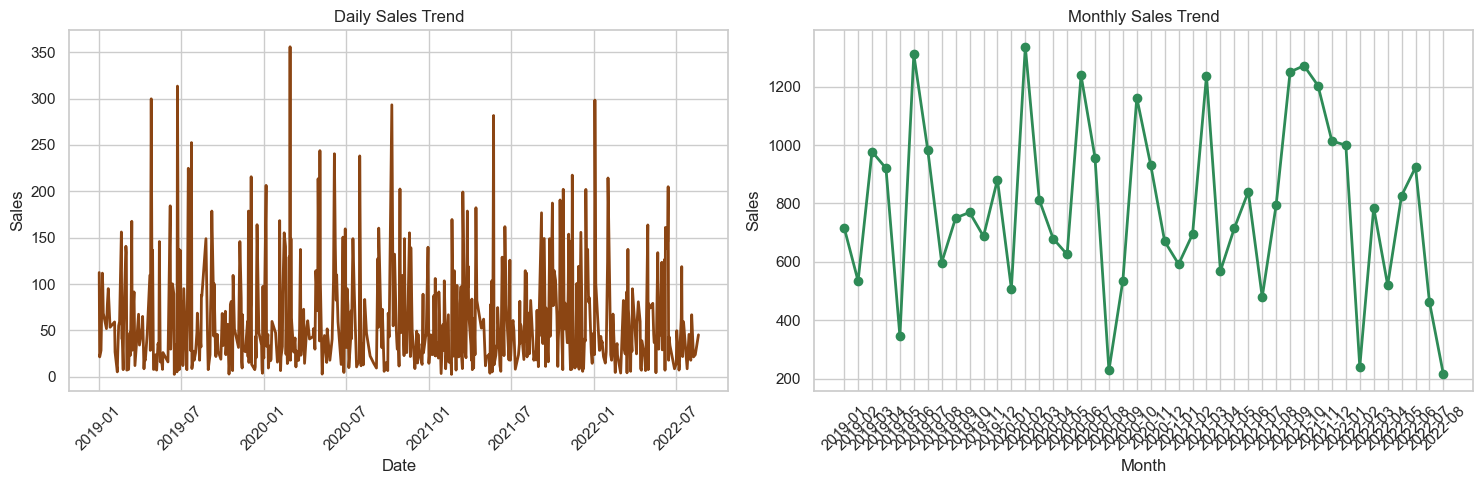

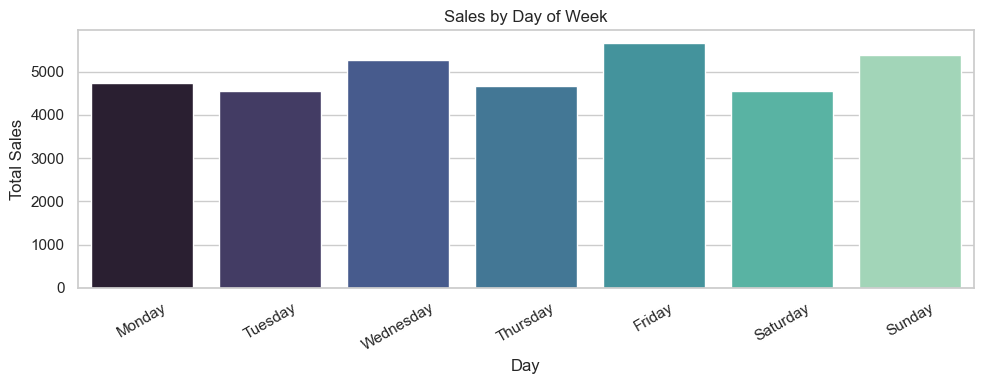

In [8]:
# ==========================================
# 7) Time-Based Sales Analysis
# ==========================================
if {"Order Date", "Sales"}.issubset(df.columns):
    temp = df.dropna(subset=["Order Date", "Sales"]).copy()

    daily_sales = temp.groupby(temp["Order Date"].dt.date)["Sales"].sum()
    monthly_sales = temp.groupby(temp["Order Date"].dt.to_period("M"))["Sales"].sum()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(daily_sales.index, daily_sales.values, color="#8B4513", linewidth=2)
    axes[0].set_title("Daily Sales Trend")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Sales")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o", color="#2E8B57", linewidth=2)
    axes[1].set_title("Monthly Sales Trend")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Sales")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    if "Day_Name" in temp.columns:
        day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        day_sales = temp.groupby("Day_Name")["Sales"].sum().reindex(day_order)

        plt.figure(figsize=(10, 4))
        sns.barplot(x=day_sales.index, y=day_sales.values, palette="mako")
        plt.title("Sales by Day of Week")
        plt.xlabel("Day")
        plt.ylabel("Total Sales")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print("Order Date and Sales columns are required for time analysis.")

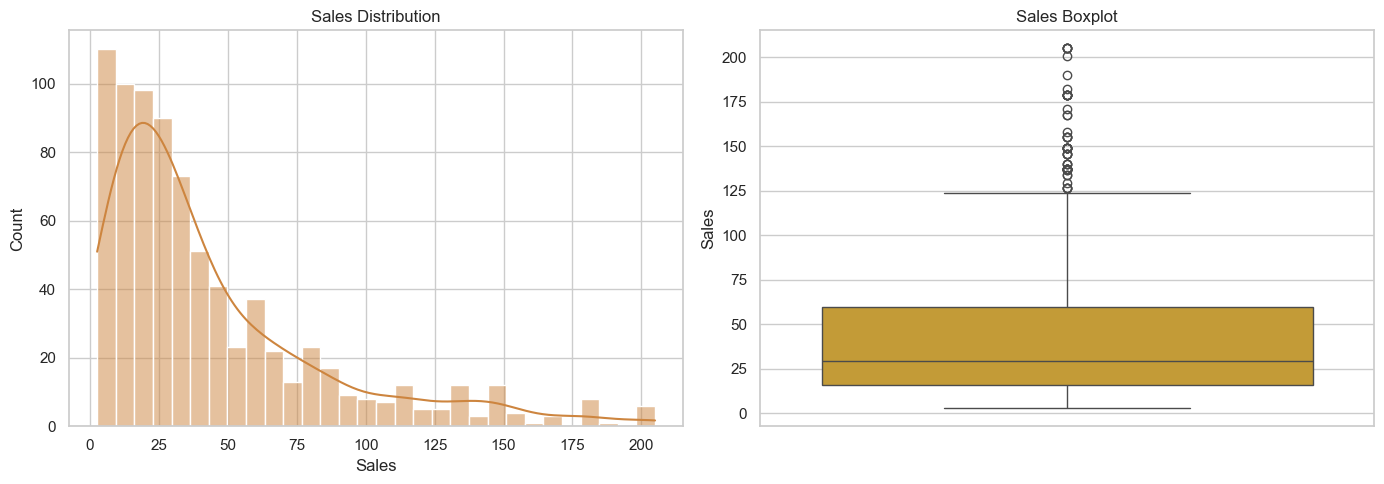

In [9]:
# ==========================================
# 8) Distribution + Outlier View
# ==========================================
if "Sales" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df["Sales"].dropna(), bins=30, kde=True, ax=axes[0], color="#CD853F")
    axes[0].set_title("Sales Distribution")

    sns.boxplot(y=df["Sales"], ax=axes[1], color="#DAA520")
    axes[1].set_title("Sales Boxplot")

    plt.tight_layout()
    plt.show()
else:
    print("Sales column not available for distribution analysis.")

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer Name,,,,,,,
Terri Farra,426,3,289.11,3,4,4,11
Nealson Cuttler,454,1,281.68,3,3,4,10
Don Flintiff,383,3,278.01,3,4,4,11
Brice Romera,679,1,246.21,2,1,4,7
Ailey Brash,418,2,206.60,3,4,4,11
Teddi Crowthe,68,1,204.93,4,4,4,12
Daniel Heinonen,1122,1,204.93,1,1,4,6
Shelli Keynd,990,1,204.93,1,4,4,9
Nanny Lush,1152,1,204.93,1,3,4,8


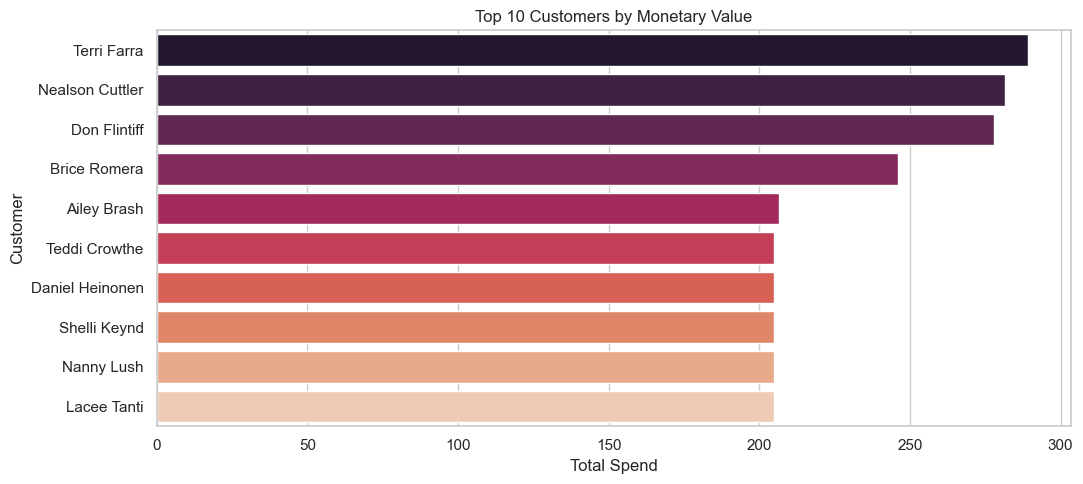

In [10]:
# ==========================================
# 9) Feature Engineering: RFM (if columns exist)
# ==========================================
required_rfm_cols = {"Order Date", "Sales"}
customer_col = None

if "Customer Name" in df.columns:
    customer_col = "Customer Name"
elif "Customer_Name" in df.columns:
    customer_col = "Customer_Name"

if customer_col and required_rfm_cols.issubset(df.columns):
    rfm_base = df.dropna(subset=[customer_col, "Order Date", "Sales"]).copy()
    snapshot_date = rfm_base["Order Date"].max() + pd.Timedelta(days=1)

    if "Order ID" in rfm_base.columns:
        freq_series = rfm_base.groupby(customer_col)["Order ID"].nunique()
    else:
        # fallback frequency: count rows/orders
        freq_series = rfm_base.groupby(customer_col).size()

    recency_series = rfm_base.groupby(customer_col)["Order Date"].max().apply(lambda d: (snapshot_date - d).days)
    monetary_series = rfm_base.groupby(customer_col)["Sales"].sum()

    rfm = pd.concat([recency_series, freq_series, monetary_series], axis=1)
    rfm.columns = ["Recency", "Frequency", "Monetary"]

    # Score bins (robust for small unique counts)
    rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"), q=4, labels=[4, 3, 2, 1]).astype(int)
    rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)
    rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)
    rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

    display(rfm.sort_values("Monetary", ascending=False).head(10))

    top_customers = rfm.sort_values("Monetary", ascending=False).head(10)
    plt.figure(figsize=(11, 5))
    sns.barplot(x=top_customers["Monetary"].values, y=top_customers.index, palette="rocket")
    plt.title("Top 10 Customers by Monetary Value")
    plt.xlabel("Total Spend")
    plt.ylabel("Customer")
    plt.tight_layout()
    plt.show()
else:
    print("RFM step skipped: customer/date/sales fields are not all available.")

## 🧠 Business Insights & Recommendations

### Key Findings
- Product/customer concentration usually shows a few high performers driving a large share of revenue.
- Time-based patterns reveal peak demand windows useful for staffing and promotions.
- Sales distribution often contains outliers, so median and IQR should be tracked beside average order value.
- RFM helps identify VIP customers and at-risk high-value customers.

### Actionable Recommendations
1. Promote high-margin and high-demand coffee types together (bundle strategy).
2. Increase staff during top demand days/times and run micro-campaigns during low-demand windows.
3. Use loyalty offers and targeted retention campaigns for high-monetary customers with increasing recency.
4. Track monthly KPI dashboard: Total Sales, AOV, Repeat Rate, and Top 10 Customer Contribution.

---

## ✅ Notebook Complete
This notebook now provides an end-to-end workflow: loading, cleaning, feature engineering, EDA, segmentation, and business recommendations.